# 5. R is a field, and it can be learned as one

Notebook 1 asked whether a robot could learn how much to trust a camera, and treated
$\mathbf{R}$ as one covariance for the whole drive. That was a simplification, and this
notebook removes it.

The reason it matters is not tidiness. The planner does not want $\mathbf{R}$ for the
drive that happened; it wants $\mathbf{R}$ **at a pose it is considering and has never
visited**. The deployed way of producing that is
`reliability.planning_covariance.plan_covariance`:

$$\mathbf{R}_{\text{plan}} = \mathbf{R}_{\text{visible}} + (1-\tau)^{\gamma}\,
  (\mathbf{R}_{\text{miss}} - \mathbf{R}_{\text{visible}})$$

a scalar trust $\tau$ from a Gaussian process, blended between two asserted endpoints
(`r_visible_uv = 2.5 px`, `r_miss_uv` = 40 px offline or 120 px at runtime — a constant
that is still formally unregistered, `DECISION_r_miss.md` does not exist, and
`MissEndpointPolicy.require_reconciled()` raises rather than let either number be
quoted).

This notebook measures what $\mathbf{R}$ actually is across the floor, learns it as a
field with an honest posterior, and compares the two. **Three findings, all checkable:**

1. the blend can only change $\mathbf{R}$'s **size**, never its shape — and the real
   $\mathbf{R}$ is elongated by 1.7× typically and up to 2.4×;
2. its "perfectly visible" endpoint is **wider than the measured noise everywhere**, so
   no value of $\tau$ in $[0,1]$ reproduces reality;
3. with the endpoints that far apart, the blend is **96% miss-endpoint at $\tau = 0.9$**,
   so for practical purposes it is not blending at all.

### Evidence scope

The four recorded single-camera drives in the AWS warehouse, 866 readings pooled.
Ground truth is used here, deliberately and offline: this is a **calibration artifact**,
the sort of thing you build once before deployment, not something a robot computes while
driving. Notebook 1 covers what happens if you try to do it online.

In [1]:
import notebook_data as nd
import notebook_model as nm
import notebook_views as nv
import numpy as np

nv.style()
LEAD = "camera_A"
DRIVES = ["aws_aisle_east_north", "aws_apron_west_to_east",
          "aws_aisle_west_north", "aws_mid_cross_east"]

nd.load_capture(DRIVES[0])                    # selects the world these drives live in
models = nd.camera_models()
rows = nm.field_observations(DRIVES, LEAD, models)

print(f"{len(rows)} readings pooled from {len(DRIVES)} drives, all with ground truth")

866 readings pooled from 4 drives, all with ground truth


## Why a single number cannot be right

An observation is a pixel before it is a position, and the map from one to the other is
the projection's derivative $\mathbf{J}$. A detector error that is isotropic **in
pixels** therefore lands on the floor as

$$\mathbf{R} = \sigma_{\text{px}}^2\, \mathbf{J}\mathbf{J}^{\!\top}$$

which is anisotropic, oriented, and different at every point — because $\mathbf{J}$ is.
Near the camera it looks steeply down and a pixel is cheap; far away it looks along the
floor and the same pixel is dear, and stretched along the line of sight.

So $\mathbf{R}$ has a **shape** that geometry supplies for free at any pose, and a
**scale** that it does not. The scale is the only thing left to learn.

In [2]:
one_drive = nm.Sequence(nd.load_capture(DRIVES[0], models=models),
                        nd.load_truth(DRIVES[0]), window=nd.route_window(DRIVES[0]))
sigma_px, trace = nm.learn_sigma_px(one_drive, models)
path = " -> ".join(f"{h['sigma_px']:.2f}" for h in trace[:5])

print(f"learning that one number from one drive, with no ground truth at all: "
      f"{sigma_px:.2f} px")
print(f"  ({path} ... over 12 passes)")
print("\nIt converges, and it shrinks — the same pathology notebook 1 documents, and")
print("changing twelve parameters to one does not cure it. So the field below is built")
print("the honest way, against ground truth, offline.")

learning that one number from one drive, with no ground truth at all: 0.37 px
  (0.84 -> 0.56 -> 0.46 -> 0.42 -> 0.39 ... over 12 passes)

It converges, and it shrinks — the same pathology notebook 1 documents, and
changing twelve parameters to one does not cure it. So the field below is built
the honest way, against ground truth, offline.


## The field

At every floor point, weight the readings by how near they were and run exactly the
conjugate update notebook 1 uses — but on the *scale* of a known shape, so the conjugate
prior is inverse-gamma rather than inverse-Wishart:

$$a(x) = a_0 + \tfrac{d}{2}\sum_k w_k(x), \qquad
  b(x) = b_0 + \tfrac12 \sum_k w_k(x)\, \operatorname{tr}\!\big(\mathbf{M}_k^{-1}
  \mathbf{e}_k\mathbf{e}_k^{\!\top}\big)$$

with $w_k(x)$ a Gaussian kernel in floor position and
$\mathbf{e}_k = \mathbf{v}_k - \text{lean}(x)$.

The lean has to come out first, and it is a field too. A first attempt without that step
returned 9 to 13 "pixels" of noise, which is nonsense for a detector that places a box to
about a pixel: a residual measured about zero is mostly bias, and dividing a bias by the
local centimetres-per-pixel turns it into a large apparent pixel error that shrinks with
range because the divisor grows.

Because the posterior is a distribution rather than a point, a credible interval comes
out for free — **wide where no drive went, narrow where many did**.

In [3]:
field = nm.R_field_learned(rows, models, LEAD)

nv.report_the_R_field(field, rows, models)

  learned from 866 readings across 4 drives, kernel 1.5 m

  place                               lean, cm  sigma_px        90% band   data           R, cm
  up the aisle, close in      ( -2.4, -9.0)      2.28  [2.16, 2.40]    241     1.56 x 1.79
  up the aisle, half way      ( -1.4, -8.3)      1.24  [1.16, 1.32]    169     1.37 x 2.07
  up the aisle, far end       ( -1.6, -7.4)      1.05  [0.97, 1.14]    100     1.56 x 3.13
  out on the west apron       ( -5.8, -8.8)      1.55  [1.43, 1.70]     89     0.83 x 1.39
  a corner no drive reached   ( -1.4, -8.3)      1.66  [1.24, 2.62]      2     2.26 x 4.97

  The last row is the point of the whole exercise: the field does not
  invent a number where nothing drove, it widens its band and says so.


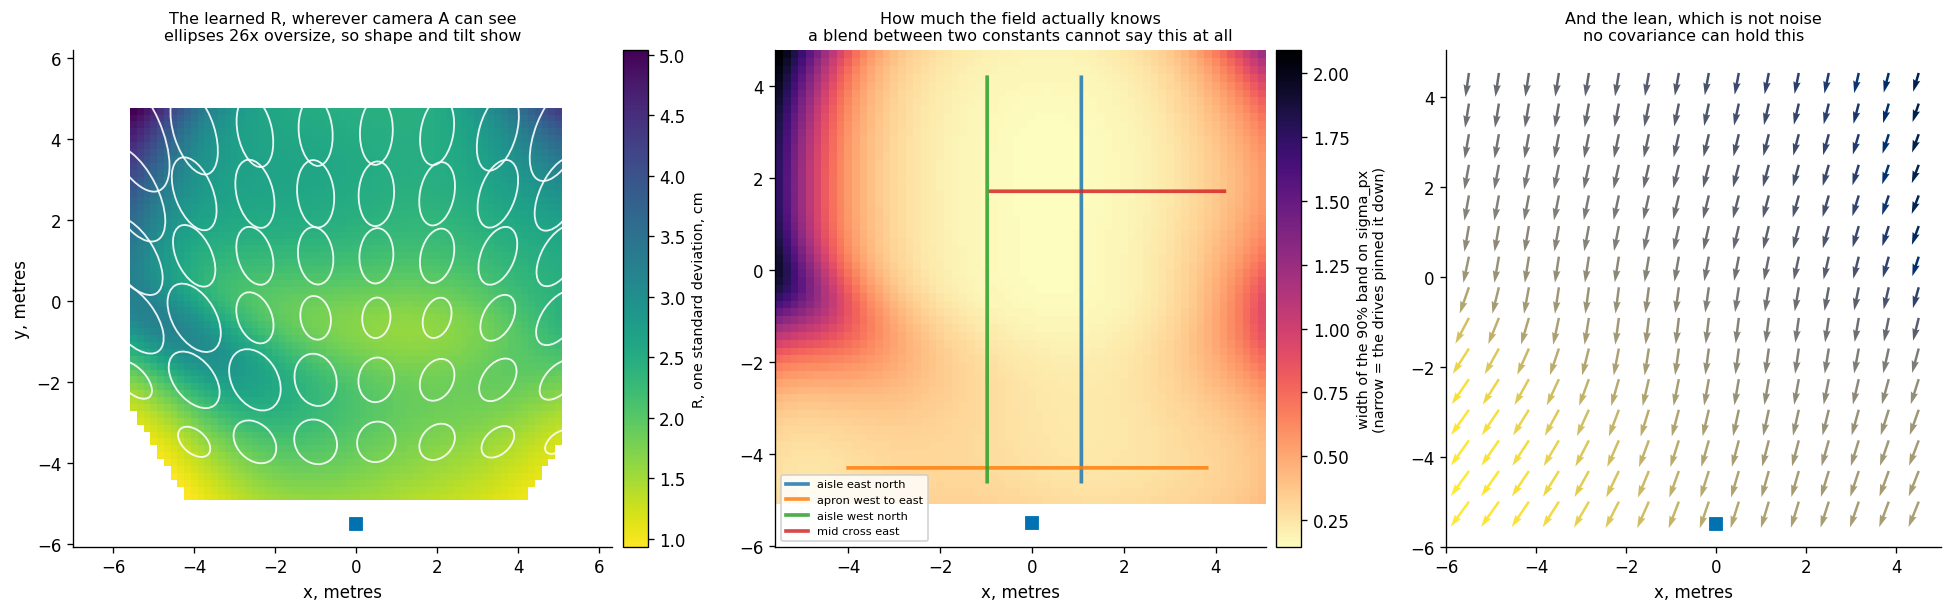

In [4]:
nv.the_R_field(field, rows, models)

The middle panel is the one worth dwelling on. It is not the value of $\mathbf{R}$, it is
**how much the drives actually pinned it down** — and it is the thing a blend between two
constants has no way of producing. A planner asking about a pose out in the dark corner
gets a number *and* a warning that the number is a guess.

The right panel is the lean, which is not noise and which no covariance holds. It varies
across the floor, which is why notebook 2's geometric prediction is pose-dependent.

## Against the blend

Now the same question the deployed code answers, asked of both.

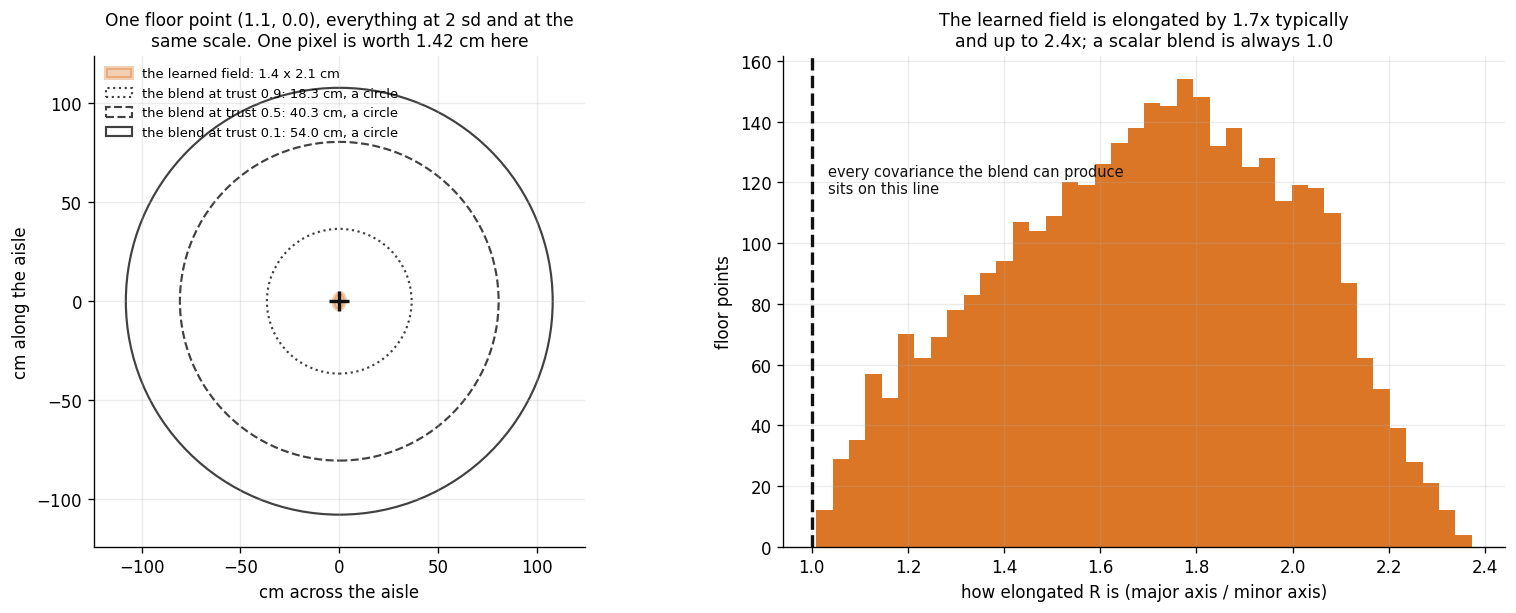

In [5]:
nv.field_against_blend(field, rows, models)

### What the numbers say

At the mid-aisle point, everything at two standard deviations and the same scale:

| | at that point |
|---|---|
| the learned field | **1.4 × 2.1 cm**, tilted |
| the blend at trust 0.9 | 18.3 cm, a circle |
| the blend at trust 0.5 | 40.3 cm, a circle |
| the blend at trust 0.1 | 54.0 cm, a circle |

**1. It cannot change shape.** Both endpoints are isotropic pixel constants, so every
covariance the blend can produce is a circle. The learned field is elongated by 1.7×
typically and up to 2.4×, and its orientation rotates with position. None of that
survives a scalar interpolation between two circles.

**2. No trust value reaches the measured noise.** The learned scale is 1.05 to 2.28 px
across the floor. The blend's *perfectly visible* endpoint is 2.5 px. So even at
$\tau = 1$ — a camera it believes completely — the blend is wider than the camera
actually is. Tuning $\tau$ cannot fix that; the endpoint is wrong.

**3. And it is barely blending.** With `r_visible_uv = 2.5` and `r_miss_uv = 40`, the
variance ratio between the endpoints is **256×** (offline) or **2304×** (runtime). With
$\gamma = 1$ that means at $\tau = 0.9$ the miss endpoint already supplies **96%** of the
variance; you need $\tau > 0.999$ before the visible endpoint contributes even a fifth.
For all practical trust values the blend returns its miss endpoint — the constant that
is formally unregistered.

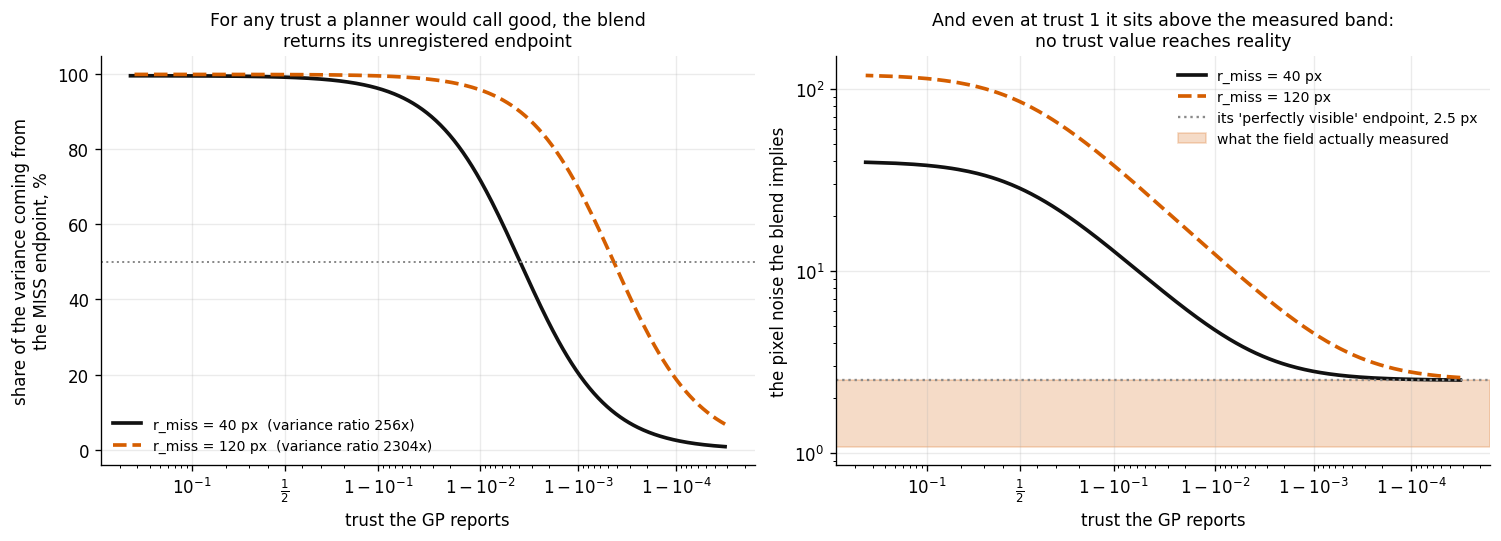

In [6]:
nv.blend_dominance(r_visible_uv=2.5, r_miss_uv=(40.0, 120.0), field=field)

## What to do instead

Not "replace the GP" — the GP is doing a real job and doing it in the right place. The
problem is that one scalar is being asked to carry two different physical quantities.
They separate cleanly:

| quantity | what sets it | needs data? | where it lives |
|---|---|---|---|
| **whether a reading arrives at all** | occlusion, detector behaviour, lighting | **yes** — this is what a GP is for | $\tau(x,y)$ |
| **$\mathbf{R}$'s shape and orientation** | the projection's derivative | **no** — closed form at any pose | $\mathbf{J}\mathbf{J}^{\!\top}$ |
| **$\mathbf{R}$'s scale** | how many pixels the detector is wrong by | yes, but one field with a posterior | $\sigma_{\text{px}}(x,y)$ |
| **the lean** | robot geometry and viewing angle | no — predictable, notebook 2 | $\mathbf{b}(x,y)$ |

Blending the first two into one scalar is what makes the endpoints unmeasurable: there
is no experiment that isolates "the covariance when the camera misses", because when it
misses there is no reading to measure. That is why `DECISION_r_miss.md` has never been
written. Split them and every remaining quantity is something you can actually measure.

**An honest caveat.** The scale field is not fully explained by geometry. Across the four
routes, dividing by the projection cuts the spread from 74% to 52% — real but partial —
and *within* the analysis drive it does not help at all: the near band carries about
three times the pixel error of everything beyond 3.5 m, and neither frame-edge clipping
nor the start-up transient accounts for it. So there is genuine empirical spatial
structure left over. That residue is exactly what a learned field is for, and it is the
honest argument for keeping a data-driven component — just not the one currently wired
in.

---

*Four recorded Gazebo drives in the AWS warehouse, 866 readings, no synthetic data.
Ground truth is used deliberately: this is an offline calibration artifact, not
something a robot computes while driving. Every estimator is shared through
`notebook_model.py` and every figure through `notebook_views.py`.*